In [1]:
%pip install -q pandas matplotlib seaborn scikit-learn xgboost shap

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual para que los gráficos se vean bien en el notebook
sns.set_theme(style="whitegrid")
# Esto asegura que los gráficos se muestren integrados en el notebook
%matplotlib inline

In [4]:
# Cargar la base de datos desde la subcarpeta
df_sepsis = pd.read_csv('bbdd/Supplementary Table 3. SEPSIS_FINAL.csv')

# Define aquí el nombre exacto de la columna que indica si el paciente falleció o no
columna_target = 'nombre_de_tu_columna_target' 

# Dar un primer vistazo a las primeras 5 filas
df_sepsis.head()

,Unnamed: 0,gender,admission_age,ethnicity,admission_type,admission_location,marital_status,unitdischargeoffset,hospitaldischargeoffset,los_icu,...,bun_max,sodium_min,sodium_max,glucose_min,glucose_max,urineoutput,gcs_unable,gcs_eyes,gcs_verbal,gcs_motor
0,0,1,48.966011,27,8,8,2,3249,8986,2.26,...,21.0,136.0,136.0,98.0,167.0,1248.0,0.0,3.0,5.0,6.0
1,1,1,64.126857,28,3,6,1,3107,5777,2.16,...,20.0,142.0,145.0,140.0,163.0,3295.0,0.0,4.0,5.0,6.0
2,2,0,81.929747,28,3,6,2,3461,5980,2.40,...,46.0,139.0,139.0,70.0,190.0,1769.0,0.0,3.0,1.0,6.0
3,4,1,77.496937,28,1,6,1,2064,8799,1.43,...,23.0,141.0,141.0,106.0,158.0,3195.0,1.0,1.0,0.0,1.0
4,6,1,66.301944,28,8,8,2,7866,20737,5.46,...,14.0,141.0,142.0,100.0,117.0,650.0,0.0,3.0,4.0,4.0


In [8]:
# 1. Definimos la variable objetivo exacta según el diccionario de datos
columna_target = 'hospital_expire_flag'

# 2. Eliminar columnas que no aportan al modelo (IDs y Fechas)
# Estas variables son ruido para el EDA y para el Machine Learning
columnas_a_eliminar = [
    'subject_id', 'hadm_id', 'stay_id',  # Identificadores
    'admittime', 'dischtime', 'icu_intime', 'icu_outtime', 'dod', # Fechas exactas
    'unitdischargeoffset', 'hospitaldischargeoffset', 'deathoffset' # Tiempos transcurridos (fugas de información)
]

# Eliminamos las columnas si existen en el dataframe para evitar errores
columnas_existentes_a_eliminar = [col for col in columnas_a_eliminar if col in df_sepsis.columns]
df_sepsis = df_sepsis.drop(columns=columnas_existentes_a_eliminar)

# 3. Forzar a que Pandas trate las variables numéricas que son en realidad CATEGÓRICAS como tal
columnas_categoricas = [
    columna_target, # 0 o 1
    'sepsis3',      # Indicador binario
    'gcs_unable',   # Indicador de evaluación
    'gcs_eyes',     # Valores 1 a 4
    'gcs_verbal',   # Valores 1 a 5
    'gcs_motor'     # Valores 1 a 6
]

for col in columnas_categoricas:
    if col in df_sepsis.columns:
        # Convertimos a tipo 'category' para que los gráficos y métricas las traten bien
        df_sepsis[col] = df_sepsis[col].astype('category')

# Validamos que los cambios se hayan aplicado
print("Tipos de datos corregidos. Variables categóricas actuales:")
print(df_sepsis.select_dtypes(include=['category', 'object']).columns.tolist())

Tipos de datos corregidos. Variables categóricas actuales:
['hospital_expire_flag', 'gcs_unable', 'gcs_eyes', 'gcs_verbal', 'gcs_motor']


In [9]:
print("--- Información del Dataset ---")
df_sepsis.info()

print("\n--- Porcentaje de Valores Nulos (Missings) por Columna ---")
porcentaje_nulos = (df_sepsis.isnull().sum() / len(df_sepsis)) * 100
print(porcentaje_nulos[porcentaje_nulos > 0].sort_values(ascending=False))

print("\n--- Resumen Estadístico: Variables Numéricas (Signos Vitales, Labs, etc.) ---")
# Esto mostrará medias, percentiles, máximos y mínimos (ej. para heart_rate_max)
display(df_sepsis.describe()) 

print("\n--- Resumen Estadístico: Variables Categóricas (Glasgow, Sepsis3, Target) ---")
# Al poner include=['category'], mostrará la frecuencia, el valor más repetido (top), etc.
display(df_sepsis.describe(include=['category']))

--- Información del Dataset ---
<class 'pandas.DataFrame'>
RangeIndex: 23706 entries, 0 to 23705
Data columns (total 49 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   Unnamed: 0            23706 non-null  int64   
 1   gender                23706 non-null  int64   
 2   admission_age         23706 non-null  float64 
 3   ethnicity             23706 non-null  int64   
 4   admission_type        23706 non-null  int64   
 5   admission_location    23706 non-null  int64   
 6   marital_status        23706 non-null  int64   
 7   los_icu               23706 non-null  float64 
 8   los_hospital          23706 non-null  float64 
 9   hospital_expire_flag  23706 non-null  category
 10  apsiii                23706 non-null  int64   
 11  apsiii_prob           23706 non-null  float64 
 12  hr_score              23706 non-null  float64 
 13  mbp_score             23706 non-null  float64 
 14  temp_score            23706 non-n

,Unnamed: 0,gender,admission_age,ethnicity,admission_type,admission_location,marital_status,los_icu,los_hospital,apsiii,...,wbc_max,creatinine_min,creatinine_max,bun_min,bun_max,sodium_min,sodium_max,glucose_min,glucose_max,urineoutput
count,23706.000000,23706.000000,23706.000000,23706.000000,23706.000000,23706.000000,23706.000000,23706.000000,23706.000000,23706.000000,...,23706.000000,23706.000000,23706.000000,23706.000000,23706.000000,23706.000000,23706.000000,23706.000000,23706.000000,23706.000000
mean,26707.324264,0.577955,66.542254,24.721758,5.708977,4.705349,1.731924,5.066048,11.998687,54.307391,...,15.606034,1.345774,1.664566,25.353331,30.497740,136.692916,140.020965,106.579331,194.953656,1778.963236
std,15459.326540,0.493896,16.396447,7.329969,1.627895,2.713927,1.080310,6.492498,12.300886,25.389308,...,12.637591,1.334191,1.687351,20.769628,24.271335,5.361231,5.252501,35.431904,104.775314,1263.055431
min,0.000000,0.000000,18.065797,0.000000,0.000000,0.000000,0.000000,0.080000,-0.779861,6.000000,...,0.100000,0.100000,0.100000,1.000000,2.000000,74.000000,107.000000,0.120000,40.000000,-14850.000000
25%,13352.250000,0.000000,56.653966,27.000000,5.000000,2.000000,1.000000,1.460000,5.030035,36.000000,...,9.900000,0.700000,0.800000,13.000000,15.000000,134.000000,137.000000,85.000000,137.000000,940.000000
50%,26635.500000,1.000000,68.021850,28.000000,5.000000,6.000000,1.000000,2.800000,8.224306,48.000000,...,13.800000,0.900000,1.100000,18.000000,22.000000,137.000000,140.000000,100.000000,170.000000,1575.000000
75%,40160.250000,1.000000,79.098596,28.000000,7.000000,8.000000,2.000000,5.850000,14.699826,68.000000,...,18.700000,1.400000,1.800000,30.000000,37.000000,140.000000,142.000000,122.000000,217.000000,2330.000000
max,53567.000000,1.000000,102.865603,32.000000,8.000000,10.000000,4.000000,101.730000,249.585417,189.000000,...,471.700000,22.100000,32.300000,224.000000,261.000000,175.000000,185.000000,477.000000,2275.000000,30595.000000



--- Resumen Estadístico: Variables Categóricas (Glasgow, Sepsis3, Target) ---


,hospital_expire_flag,gcs_unable,gcs_eyes,gcs_verbal,gcs_motor
count,23706,23706.0,23706.0,23706.0,23706.0
unique,2,3.0,5.0,7.0,7.0
top,0,0.0,4.0,5.0,6.0
freq,20070,21232.0,8567.0,8571.0,14429.0


C:\Users\Joel\AppData\Local\Temp\ipykernel_22276\3515502975.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_sepsis, x=columna_target, palette="viridis")


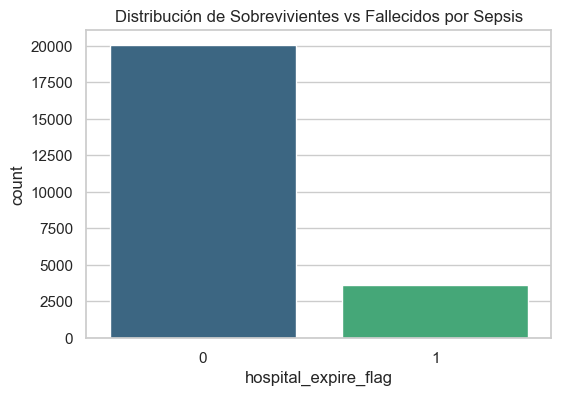

In [10]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df_sepsis, x=columna_target, palette="viridis")
plt.title("Distribución de Sobrevivientes vs Fallecidos por Sepsis")
plt.show()

C:\Users\Joel\AppData\Local\Temp\ipykernel_22276\53200789.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_sepsis, x=columna_target, y=var, ax=axes[i], palette="Set2")
C:\Users\Joel\AppData\Local\Temp\ipykernel_22276\53200789.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_sepsis, x=columna_target, y=var, ax=axes[i], palette="Set2")
C:\Users\Joel\AppData\Local\Temp\ipykernel_22276\53200789.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_sepsis, x=columna_target, y=var, ax=axes[i], palette="Set2")
C:\User

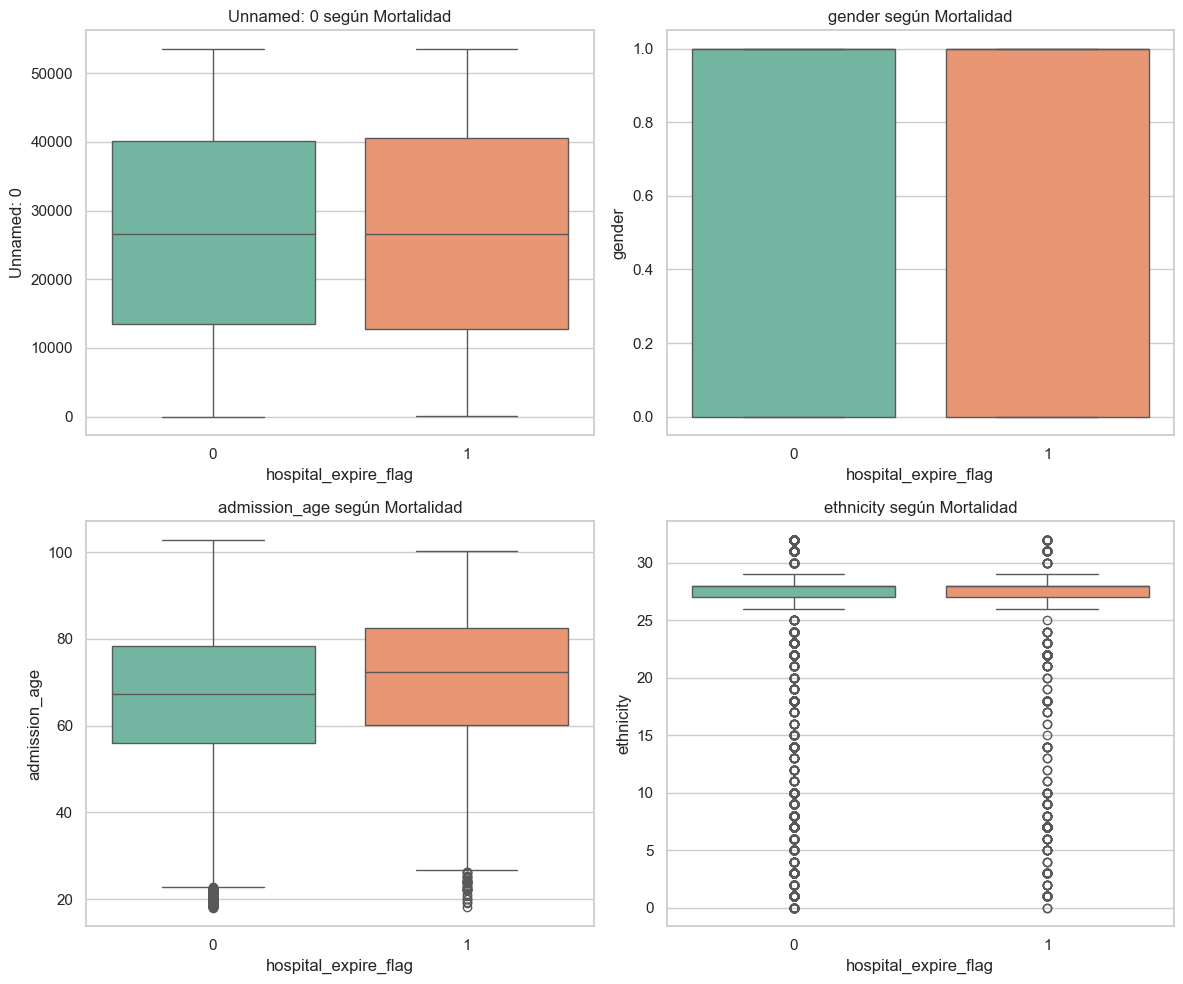

In [11]:
# Seleccionamos algunas variables numéricas clave para no saturar la pantalla
variables_numericas = df_sepsis.select_dtypes(include=['float64', 'int64']).columns.tolist()
if columna_target in variables_numericas:
    variables_numericas.remove(columna_target)

# Cambia el [0:4] por el rango de variables que quieras visualizar
vars_a_plotear = variables_numericas[0:4] 

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, var in enumerate(vars_a_plotear):
    sns.boxplot(data=df_sepsis, x=columna_target, y=var, ax=axes[i], palette="Set2")
    axes[i].set_title(f'{var} según Mortalidad')

plt.tight_layout()
plt.show()

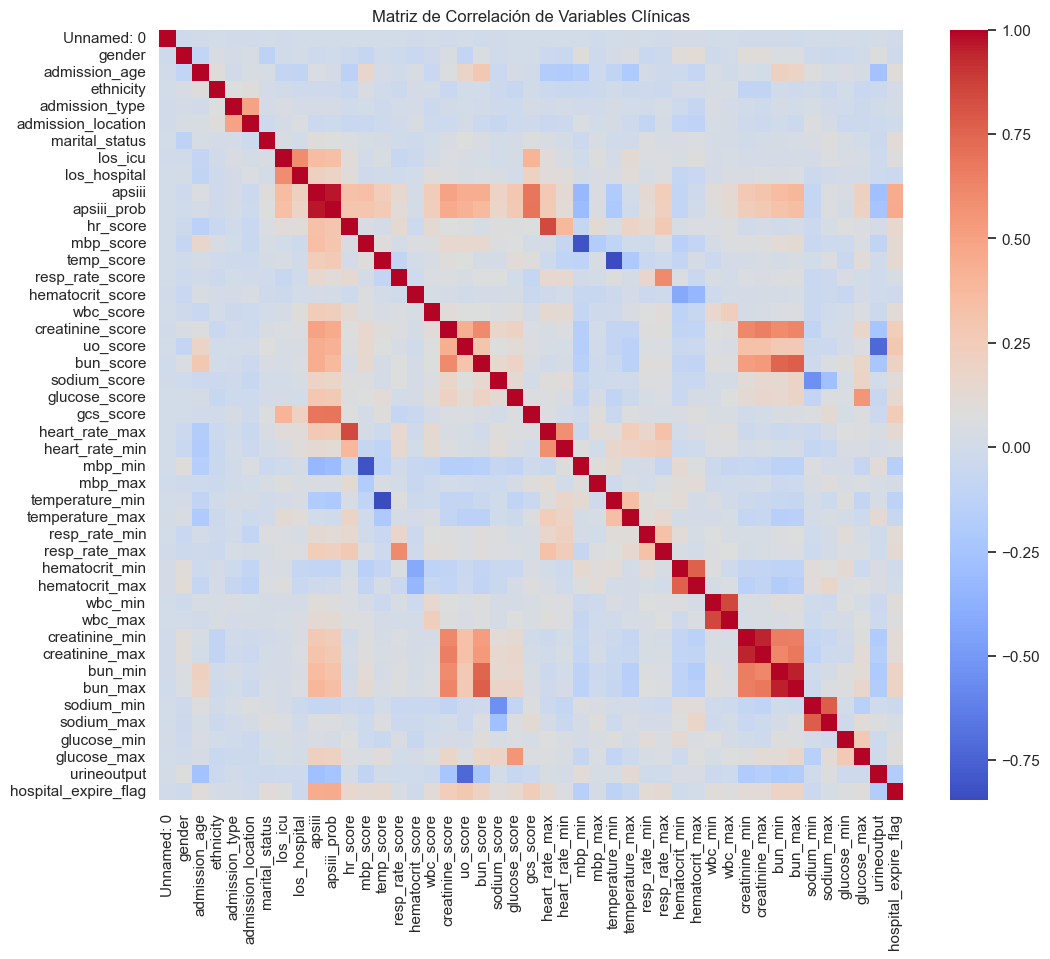

In [12]:
plt.figure(figsize=(12, 10))
# Calculamos correlación de Pearson solo con variables numéricas
matriz_corr = df_sepsis[variables_numericas + [columna_target]].corr()
sns.heatmap(matriz_corr, annot=False, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlación de Variables Clínicas")
plt.show()